### **Importations**

In [2]:
# Utilitaires de base
import builtins
import pandas as pd

# Suivi des expriences (MLflow & DagsHub)
import dagshub
import mlflow

# Scikit-Learn : Sparation des donnes et mtriques d'valuation
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    f1_score, 
    fbeta_score, 
    precision_score, 
    recall_score
)

# TensorFlow / Keras : Cration et entranement du modle Deep Learning
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.layers import TextVectorization


#### **DagsHub & MLflow Init**

In [3]:
# Initialisation de la connexion DagsHub avec les identifiants de votre dépôt et activation du mode MLflow
# PATCH WINDOWS : Force l'utilisation de l'encodage UTF-8 lors de l'écriture des fichiers.

_original_open = builtins.open
def _utf8_open(*args, **kwargs):
    mode = kwargs.get('mode', args[1] if len(args) > 1 else 'r')
    if 'b' not in mode and 'encoding' not in kwargs:
        kwargs['encoding'] = 'utf-8'
    return _original_open(*args, **kwargs)
builtins.open = _utf8_open

dagshub.init(repo_owner='Oscar-AS', repo_name='disaster-tweets-project', mlflow=True)

# Définition du nom du dossier (expérience) dans MLflow où toutes nos métriques seront classées
mlflow.set_experiment("Disaster_Tweets")

# Affichage d'un message console pour confirmer que le tracking est bien connecté
print("MLflow activé avec succès sur DagsHub !")


Accessing as Oscar-AS

Initialized MLflow to track repo "Oscar-AS/disaster-tweets-project"

Repository Oscar-AS/disaster-tweets-project initialized!

MLflow activé avec succès sur DagsHub !


#### **Importation Données**

In [4]:

# Chargement des données
df = pd.read_csv("Base/tweets.csv")

### **Séparation des données**

In [5]:

# Séparation Train/Test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['target'], test_size=0.2, random_state=42, stratify=df['target']
)

# Affiche dans la console le nombre de tweets utilisés pour l'entraînement
print(f"Taille de l'entraînement : {len(X_train)}")
# Affiche dans la console le nombre de tweets gardés pour le test
print(f"Taille du test : {len(X_test)}")


Taille de l'entraînement : 9096
Taille du test : 2274


#### **Implémentation des modèles (Réseaux de Neurones avec TensorFlow/Keras)**

In [6]:

# Définition de la taille maximale du vocabulaire autorisé (les 15000 mots les plus fréquents)
MAX_VOCAB_SIZE = 15000
# Définition de la taille maximale d'une phrase (tronquée si plus longue, remplie par des 0 si plus courte)
MAX_SEQUENCE_LENGTH = 128

# Instanciation de la couche de Vectorisation
vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE, # Limite du vocabulaire
    output_mode='int',         # Chaque mot sera remplacé par un nombre entier
    output_sequence_length=MAX_SEQUENCE_LENGTH # Fixe la longueur de toutes les séquences à 128
)

# Apprentissage du vocabulaire : on lit le texte d'entraînement pour créer le dictionnaire mot -> entier
vectorizer.adapt(X_train.to_numpy())

# Fonction utilitaire pour préparer les données afin que TensorFlow s'entraîne plus vite
def prepare_tf_dataset(X, y, batch_size=32):
    # Création d'un dataset TensorFlow à partir de nos listes Python (X et y)
    dataset = tf.data.Dataset.from_tensor_slices((X, y))
    # Groupement des données en paquets (batches) de 32, et mise en mémoire cache dynamique (AUTOTUNE)
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    # Retourne le dataset optimisé
    return dataset

# Création du Dataset d'entraînement accéléré
train_ds = prepare_tf_dataset(X_train, y_train)
# Création du Dataset de test accéléré
test_ds = prepare_tf_dataset(X_test, y_test)

# Importation du module MLflow dédié à TensorFlow
import mlflow.tensorflow
# Activation du suivi automatique (enregistrera la loss, les paramètres et les modèles à chaque epoch sans coder manuellement)
mlflow.tensorflow.autolog(log_models=True)


#### **Modèle LSTM (Long Short-Term Memory) Simple**

##### **Description du modèle**
Le LSTM est l'architecture classique des réseaux de neurones pour le traitement de texte. Il appartient à la famille des Réseaux de Neurones Récurrents (RNN).

##### **Explication du fonctionnement**
Contrairement aux réseaux classiques qui traitent l'information d'un bloc, le LSTM lit le texte **mot par mot, de gauche à droite**. Il possède une "mémoire interne" (une bande transporteuse mathématique) qui lui permet de se souvenir du début de la phrase quand il arrive à la fin. Cela lui permet de comprendre le contexte.

##### **Pourquoi l'utiliser ici?**
C'est un modèle d'introduction parfait pour le Deep Learning sur du texte. Il saisit mieux le sens global qu'un simple modèle ML classique, mais reste rapide à entraîner.


In [7]:
# Importation des types de couches (layers) et de l'architecture séquentielle (models) de Keras
from tensorflow.keras import layers, models
# Importation de la fonction générant un rapport complet de classification (F1, Precision, Recall, etc.)
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score, accuracy_score, fbeta_score

# Démarrage manuel d'une instance (run) MLflow nommée "3.1_LSTM_Simple"
with mlflow.start_run(run_name="LSTM_Simple"):
    # Définition de la métrique F2-Score pour Keras
    def f2_score(y_true, y_pred):
        y_true = tf.cast(y_true, tf.float32)
        y_pred = tf.cast(tf.greater(y_pred, 0.5), tf.float32)
        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1 - y_pred))
        precision = tp / (tp + fp + tf.keras.backend.epsilon())
        recall = tp / (tp + fn + tf.keras.backend.epsilon())
        return (1 + 4) * (precision * recall) / (4 * precision + recall + tf.keras.backend.epsilon())

    # Initialisation d'un réseau de neurones en couches successives (Sequential)
    model_lstm = models.Sequential([
        # Couche 1 : Vectorisation (transforme le texte brut en liste d'entiers)
        vectorizer,
        # Couche 2 : Embedding (transforme l'entier en un vecteur mathématique dense de dimension 64)
        layers.Embedding(input_dim=MAX_VOCAB_SIZE, output_dim=64, mask_zero=True),
        # Couche 3 : LSTM (le coeur récurrent, avec 64 neurones)
        layers.LSTM(64),
        # Couche 4 : Couche finale (Dense) avec 1 neurone et une activation Sigmoid (renvoie une probabilité entre 0 et 1)
        layers.Dense(1, activation='sigmoid')
    ])
    
    # Compilation du modèle : définition de la fonction d'erreur (binary_crossentropy) et de l'optimiseur (adam)
    checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
        filepath='best_model_lstm.keras',
        monitor='val_f2_score',
        mode='max',
        save_best_only=True,
        verbose=1
    )

    model_lstm.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy', f2_score])
    # Lancement de l'entraînement sur 3 itérations (epochs), en validant sur test_ds à chaque fin d'epoch
    model_lstm.fit(train_ds, validation_data=test_ds, epochs=3, callbacks=[checkpoint_cb])
    
    # Recharger le meilleur modèle
    model_lstm = models.load_model('best_model_lstm.keras', custom_objects={'f2_score': f2_score})
    
    # Prédiction sur le jeu de test. Si la probabilité est > 0.5, on classe 1 (Désastre), sinon 0 (astye(int) convertit False/True en 0/1)
    y_pred_lstm = (model_lstm.predict(test_ds) > 0.5).astype(int)
     
    # Affichage du titre du rapport
    print("\n--- Rapport LSTM Simple ---")
    # Affichage des résultats complets en confrontant les vraies valeurs (y_test) aux prédictions (y_pred_lstm)
    print(classification_report(y_test, y_pred_lstm))
    
    # Suivi explicite des métriques de test dans MLflow
    mlflow.log_metric("eval_f1_macro", f1_score(y_test, y_pred_lstm, average='macro'))
    mlflow.log_metric("eval_f2_score", fbeta_score(y_test, y_pred_lstm, beta=2, average='macro'))
    
    precision_cls = precision_score(y_test, y_pred_lstm, average=None)
    recall_cls = recall_score(y_test, y_pred_lstm, average=None)
    mlflow.log_metric("eval_precision_class_0", precision_cls[0])
    mlflow.log_metric("eval_precision_class_1", precision_cls[1])
    mlflow.log_metric("eval_recall_class_0", recall_cls[0])
    mlflow.log_metric("eval_recall_class_1", recall_cls[1])
    mlflow.log_metric("eval_accuracy", accuracy_score(y_test, y_pred_lstm))
    
    # Enregistrement explicite du modèle pour la mise en production
    try:
        mlflow.tensorflow.log_model(model_lstm, "model")
    except Exception as e:
        print("Erreur lors de la sauvegarde du modèle Keras :", e)


2026/05/07 19:30:18 WARNING mlflow.tensorflow: Encountered unexpected error while inferring batch size from training dataset: Sequential model 'sequential' has no defined input shape yet.
2026/05/07 19:30:18 WARNING mlflow.tensorflow: Failed to log training dataset information to MLflow Tracking. Reason: 'ascii' codec can't decode byte 0xe2 in position 120: ordinal not in range(128)


Epoch 1/3
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.8256 - f2_score: 0.0499 - loss: 0.4534
Epoch 1: val_f2_score improved from None to 0.12246, saving model to best_model_lstm.keras

Epoch 1: finished saving model to best_model_lstm.keras


285/285 ━━━━━━━━━━━━━━━━━━━━ 40s 130ms/step - accuracy: 0.8641 - f2_score: 0.0956 - loss: 0.3657 - val_accuracy: 0.8870 - val_f2_score: 0.1225 - val_loss: 0.2948
Epoch 2/3
284/285 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9276 - f2_score: 0.1594 - loss: 0.1973
Epoch 2: val_f2_score improved from 0.12246 to 0.15234, saving model to best_model_lstm.keras

Epoch 2: finished saving model to best_model_lstm.keras
285/285 ━━━━━━━━━━━━━━━━━━━━ 16s 56ms/step - accuracy: 0.9380 - f2_score: 0.1665 - loss: 0.1776 - val_accuracy: 0.8887 - val_f2_score: 0.1523 - val_loss: 0.3180
Epoch 3/3
285/285 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9685 - f2_score: 0.1776 - loss: 0.0997
Epoch 3: val_f2_score did not improve from 0.15234
285/285 ━━━━━━━━━━━━━━━━━━━━ 16s 57ms/step - accuracy: 0.9713 - f2_score: 0.1796 - loss: 0.0921 - val_accuracy: 0.8839 - val_f2_score: 0.1514 - val_loss: 0.3690


2026/05/07 19:31:32 WARNING mlflow.tensorflow: Failed to infer model signature: Invalid dtype: object
2026/05/07 19:31:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 19:33:44 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/07 19:33:57 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmpsxwjfpe_\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 
c:\Users\Dell\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\saving\saving_lib.py:801: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables wh

72/72 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step

--- Rapport LSTM Simple ---
              precision    recall  f1-score   support

           0       0.91      0.96      0.93      1851
           1       0.76      0.59      0.66       423

    accuracy                           0.89      2274
   macro avg       0.84      0.77      0.80      2274
weighted avg       0.88      0.89      0.88      2274



2026/05/07 19:34:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/07 19:35:12 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/05/07 19:35:33 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\Dell\AppData\Local\Temp\tmp54e8lz83\model, flavor: tensorflow). Fall back to return ['tensorflow==2.21.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback. 


🏃 View run LSTM_Simple at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4/runs/76d6579f8b094136addb61f9073b1e2f
🧪 View experiment at: https://dagshub.com/Oscar-AS/disaster-tweets-project.mlflow/#/experiments/4


72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


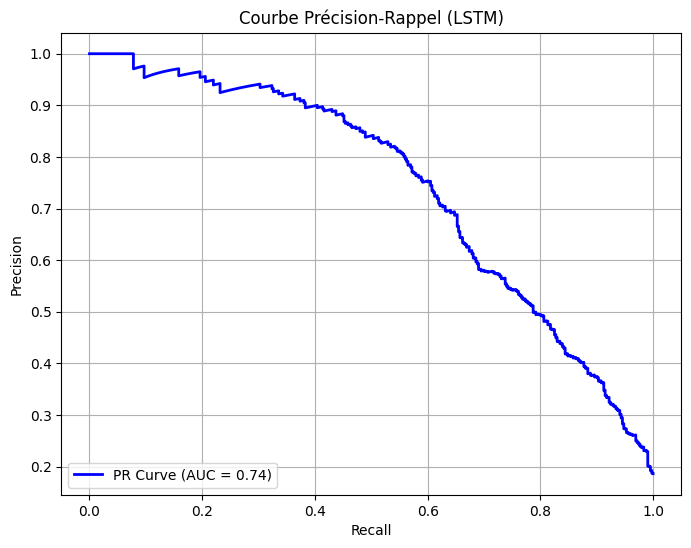

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, auc
import pandas as pd

# 1. Calcul des probabilités de prédiction
y_probs_lstm = model_lstm.predict(test_ds).ravel()

# 2. Courbe Précision-Rappel
precision, recall, _ = precision_recall_curve(y_test, y_probs_lstm)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.2f})', color='b', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Courbe Précision-Rappel (LSTM)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

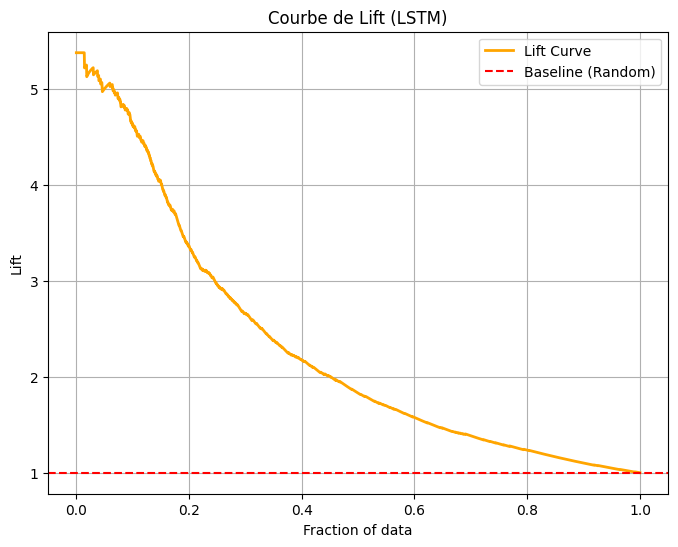

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# 3. Courbe de Lift
# Trier les probabilités par ordre décroissant
data = pd.DataFrame({'y_true': y_test, 'y_prob': y_probs_lstm})
data = data.sort_values(by='y_prob', ascending=False)
data['cumulative_data_fraction'] = np.arange(1, len(data) + 1) / len(data)
data['cumulative_positive_rate'] = data['y_true'].cumsum() / data['y_true'].sum()
data['lift'] = data['cumulative_positive_rate'] / data['cumulative_data_fraction']

plt.figure(figsize=(8, 6))
plt.plot(data['cumulative_data_fraction'], data['lift'], label='Lift Curve', color='orange', lw=2)
plt.axhline(y=1, color='r', linestyle='--', label='Baseline (Random)')
plt.xlabel('Fraction of data')
plt.ylabel('Lift')
plt.title('Courbe de Lift (LSTM)')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()